Loading data...
Training data shape: (61609, 62)
Test data shape: (41074, 61)

Missing values in training data:
209542

Engineering features...

Numeric columns: 72
Categorical columns: 6

Training set shape: (49287, 78)
Validation set shape: (12322, 78)

--- Training XGBoost Model ---

XGBoost Performance:
RMSE: 14.2028
MAE: 10.8038
R² Score: 0.5669


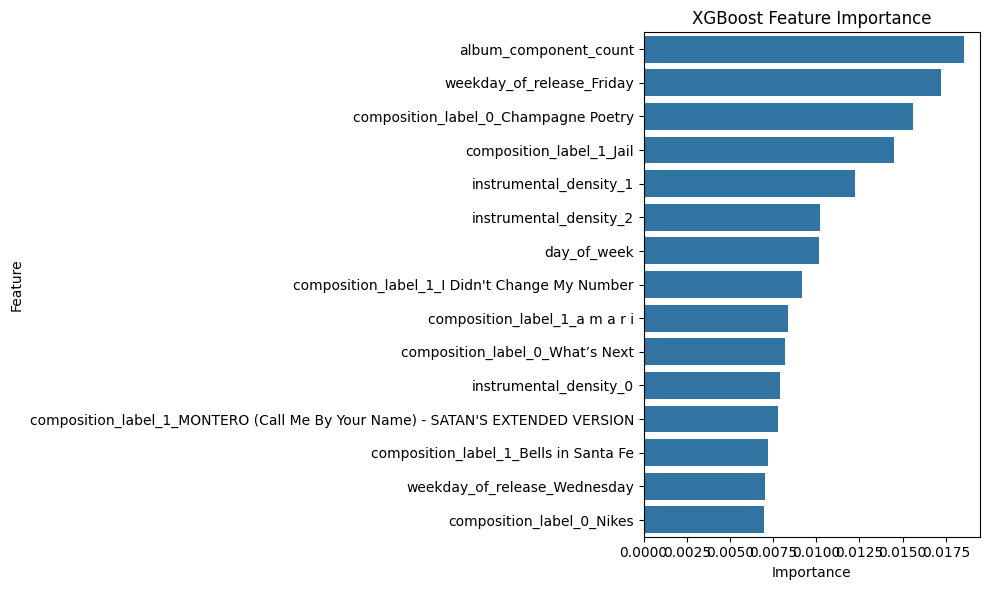


--- Training Random Forest Model ---

Random Forest Performance:
RMSE: 13.3048
MAE: 9.6348
R² Score: 0.6199

--- Model Comparison ---
           Model       RMSE        MAE        R²
0        XGBoost  14.202837  10.803764  0.566887
1  Random Forest  13.304797   9.634834  0.619927


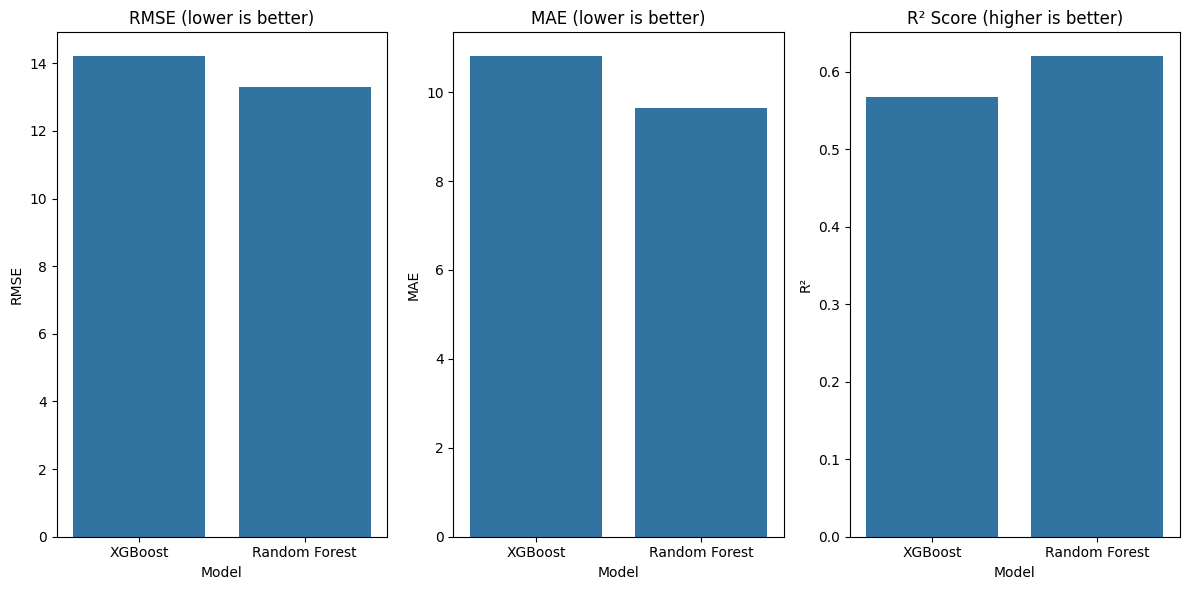


Generating predictions on test data...
Submission file created successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the data
print("Loading data...")
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Display basic information
print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Check for missing values
print("\nMissing values in training data:")
print(train_data.isnull().sum().sum())

# Feature Engineering
def engineer_features(df):
    # Create a copy to avoid modifying the original dataframe
    df_processed = df.copy()
    
    # Extract date features from publication_timestamp
    if 'publication_timestamp' in df_processed.columns:
        df_processed['publication_timestamp'] = pd.to_datetime(df_processed['publication_timestamp'])
        df_processed['year'] = df_processed['publication_timestamp'].dt.year
        df_processed['month'] = df_processed['publication_timestamp'].dt.month
        df_processed['day'] = df_processed['publication_timestamp'].dt.day
        df_processed['day_of_week'] = df_processed['publication_timestamp'].dt.dayofweek
        df_processed['is_weekend'] = df_processed['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Count number of artists
    if 'creator_collective' in df_processed.columns:
        df_processed['artist_count'] = df_processed['creator_collective'].str.count(',') + 1
    
    # Average audio features across tracks
    audio_features = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 
                      'beat_frequency', 'emotional_charge', 'groove_efficiency', 'organic_immersion']
    
    for feature in audio_features:
        cols = [col for col in df_processed.columns if feature in col]
        if cols:
            df_processed[f'avg_{feature}'] = df_processed[cols].mean(axis=1)
            df_processed[f'std_{feature}'] = df_processed[cols].std(axis=1)
    
    # Track title length
    if 'track_identifier' in df_processed.columns:
        df_processed['title_length'] = df_processed['track_identifier'].str.len()
    
    # Drop columns that won't be used for modeling
    cols_to_drop = ['track_identifier', 'creator_collective', 'publication_timestamp']
    cols_to_drop = [col for col in cols_to_drop if col in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    return df_processed

# Apply feature engineering
print("\nEngineering features...")
train_processed = engineer_features(train_data)
test_processed = engineer_features(test_data)

# Separate features and target
X = train_processed.drop('target', axis=1) if 'target' in train_processed.columns else train_processed
y = train_processed['target'] if 'target' in train_processed.columns else None

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

# Define evaluation function
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    return rmse, mae, r2

# Model 1: XGBoost
print("\n--- Training XGBoost Model ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
])

# Train XGBoost model
xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_val)
xgb_metrics = evaluate_model(y_val, xgb_preds, "XGBoost")

# Feature importance for XGBoost
if hasattr(xgb_pipeline.named_steps['regressor'], 'feature_importances_'):
    # Get feature names after preprocessing
    preprocessor = xgb_pipeline.named_steps['preprocessor']
    cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_cols)
    feature_names = numeric_cols + list(cat_features)
    
    # Get feature importances
    importances = xgb_pipeline.named_steps['regressor'].feature_importances_
    
    # Create a DataFrame for visualization
    if len(importances) == len(feature_names):
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })
        
        # Sort by importance
        feature_importance = feature_importance.sort_values('Importance', ascending=False).head(15)
        
        # Plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance)
        plt.title('XGBoost Feature Importance')
        plt.tight_layout()
        plt.show()

# Model 2: Random Forest
print("\n--- Training Random Forest Model ---")
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Random Forest model
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_val)
rf_metrics = evaluate_model(y_val, rf_preds, "Random Forest")

# Compare models
print("\n--- Model Comparison ---")
models = ['XGBoost', 'Random Forest']
rmse_values = [xgb_metrics[0], rf_metrics[0]]
mae_values = [xgb_metrics[1], rf_metrics[1]]
r2_values = [xgb_metrics[2], rf_metrics[2]]

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R²': r2_values
})
print(comparison_df)

# Plot comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='RMSE', data=comparison_df)
plt.title('RMSE (lower is better)')

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='MAE', data=comparison_df)
plt.title('MAE (lower is better)')

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R²', data=comparison_df)
plt.title('R² Score (higher is better)')

plt.tight_layout()
plt.show()

# Generate predictions on test data
print("\nGenerating predictions on test data...")
best_model = xgb_pipeline if xgb_metrics[0] < rf_metrics[0] else rf_pipeline
test_preds = best_model.predict(test_processed)

# Create submission file
submission = pd.DataFrame({
    'id': test_data['id'] if 'id' in test_data.columns else range(len(test_preds)),
    'target': test_preds
})

# Ensure predictions are within the valid range (0-100)
submission['target'] = submission['target'].clip(0, 100)

# Save submission file
submission.to_csv('submission1.csv', index=False)
print("Submission file created successfully!")